In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "--force-reinstall", "opencv-python-headless==4.9.0.80"])

CompletedProcess(args=['pip', 'install', '-q', '--force-reinstall', 'opencv-python-headless==4.9.0.80'], returncode=0)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -r /content/drive/MyDrive/FAIML-RL-26-main/requirements.txt -q

%cd /content/drive/MyDrive/FAIML-RL-26-main/part2/panda-gym
!pip install -e .

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FAIML-RL-26-main/part2/panda-gym
Obtaining file:///content/drive/MyDrive/FAIML-RL-26-main/part2/panda-gym
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: panda_gym
    Found existing installation: panda_gym 3.0.8
    Uninstalling panda_gym-3.0.8:
      Successfully uninstalled panda_gym-3.0.8
  Running setup.py develop for panda_gym
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follow

In [3]:
import argparse
import os

import gymnasium as gym
import numpy as np
from stable_baselines3 import SAC
import panda_gym  # noqa: F401 - required so Panda envs are registered
import json
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Evaluation**

In [4]:
def evaluate(model_path: str, n_episodes: int, deterministic: bool, render: bool, env_type: str, env_training: str) -> None:
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Model file not found: {model_path}. "
            "Make sure you saved your trained model with model.save(...)."
        )

    render_mode = "human" if render else "rgb_array"
    env = gym.make("PandaPush-v3", render_mode=render_mode, type=env_type, reward_type="dense")
    #TODO: load model here
    model = SAC.load(model_path)

    episode_returns = []
    successes = []

    for episode in range(1, n_episodes + 1):
        obs, info = env.reset(seed=42 + episode)
        terminated = False
        truncated = False
        episode_return = 0.0

        while not (terminated or truncated):
            action,_ = model.predict(obs, deterministic=deterministic) #TODO: get action from the model
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)

        episode_returns.append(episode_return)

        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))

        print(f"Episode {episode:03d} | return = {episode_return:.3f}")

    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean return: {returns.mean():.3f}")
    print(f"Std return:  {returns.std():.3f}")
    print(f"Min return:  {returns.min():.3f}")
    print(f"Max return:  {returns.max():.3f}")

    if successes:
        success_rate = float(np.mean(successes))
        print(f"Success rate: {success_rate:.2%}")

    results = {
      "model": model_path,
      "env_type": env_type,
      "n_episodes": n_episodes,
      "mean_return": float(returns.mean()),
      "std_return": float(returns.std()),
      "min_return": float(returns.min()),
      "max_return": float(returns.max()),
      "success_rate": float(np.mean(successes)) if successes else None
    }
    with open(f"/content/drive/MyDrive/FAIML-RL-26-main/results/evaluations/eval_{env_training}_{env_type}.json", "w") as f:
        json.dump(results, f, indent=2)

    plt.figure(figsize=(8, 4))
    plt.hist(episode_returns, bins=20, color='#534AB7', edgecolor='white')
    plt.axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode return')
    plt.ylabel('Count')
    plt.title(f'Return distribution — Evaluation on {env_type} - Training on {env_training}')
    plt.legend()
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26-main/results/evaluations/eval_{env_training}_{env_type}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, n_episodes + 1), episode_returns, color='#534AB7', linewidth=1.5)
    plt.axhline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.title(f'Return per episode — Evaluation on {env_type} - Training on {env_training}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26-main/results/evaluations/eval_{env_training}_{env_type}_per_episode.png", dpi=150)
    plt.show()

    cumulative_success = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(successes) + 1), cumulative_success, color='#0F6E56', linewidth=1.5)
    plt.axhline(np.mean(successes), color='red', linestyle='--', label=f'Final: {np.mean(successes):.2%}')
    plt.xlabel('Episode')
    plt.ylabel('Cumulative success rate')
    plt.title(f'Cumulative success rate — Evaluation on {env_type} - Training on {env_training}')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26-main/results/evaluations/eval_{env_training}_{env_type}_success_rate.png", dpi=150)
    plt.show()

**TEST UDR IN RANGE [0.5 , 6.0] - SOURCE**

Created object with mass: 1.0
Episode 001 | return = -0.606
Episode 002 | return = -0.697
Episode 003 | return = -0.016
Episode 004 | return = -1.130
Episode 005 | return = -0.386
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -1.219


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode 009 | return = -0.853
Episode 010 | return = -0.028
Episode 011 | return = -0.861
Episode 012 | return = -0.323
Episode 013 | return = -0.786
Episode 014 | return = -1.140
Episode 015 | return = -0.037
Episode 016 | return = -0.407
Episode 017 | return = -0.294
Episode 018 | return = -0.755
Episode 019 | return = -0.269
Episode 020 | return = -0.239
Episode 021 | return = -0.587
Episode 022 | return = -0.695
Episode 023 | return = -0.712
Episode 024 | return = -0.673
Episode 025 | return = -0.413
Episode 026 | return = -0.312
Episode 027 | return = -0.017
Episode 028 | return = -0.219
Episode 029 | return = -0.050
Episode 030 | return = -1.113
Episode 031 | return = -0.039
Episode 032 | return = -0.631
Episode 033 | return = -1.071
Episode 034 | return = -0.780
Episode 035 | return = -0.392
Episode 036 | return = -0.450
Episode 037 | return = -2.402
Episode 038 | return = -0.763
Episode 039 | return = -0.261
Episode 040 | return = -1.214
Episode 041 | return = -0.763
Episode 04

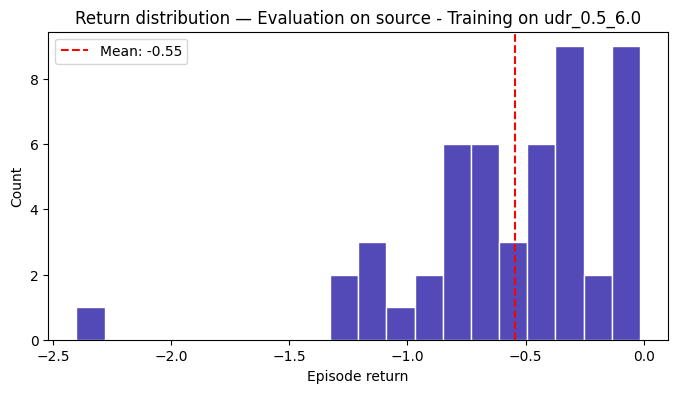

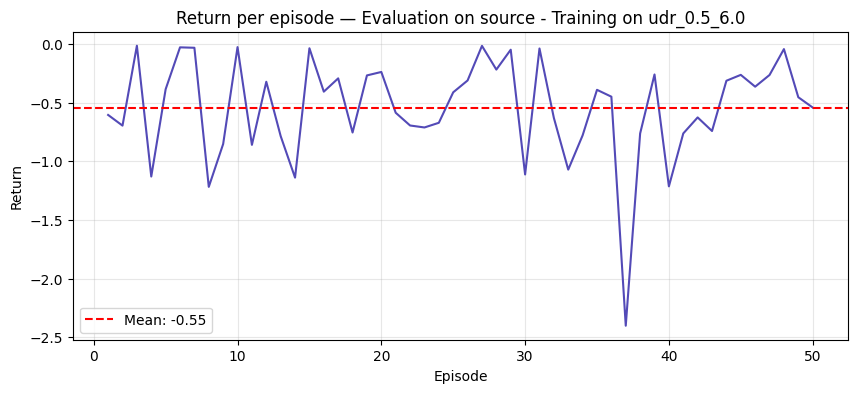

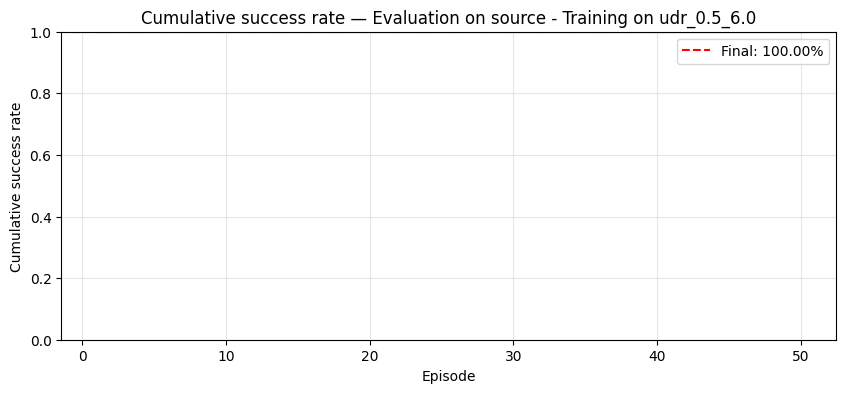

In [5]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26-main/results/udr_0.5_6.0/sac_push_udr_0.5_6.0_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="source", #args.env_type,
        env_training = "udr_0.5_6.0",
    )

**TEST UDR IN RANGE [0.5 , 8.0] - SOURCE**

Created object with mass: 1.0
Episode 001 | return = -0.598
Episode 002 | return = -0.605
Episode 003 | return = -0.016
Episode 004 | return = -0.985
Episode 005 | return = -0.308
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.385
Episode 009 | return = -0.909
Episode 010 | return = -0.028
Episode 011 | return = -0.614
Episode 012 | return = -0.258
Episode 013 | return = -0.492
Episode 014 | return = -1.147
Episode 015 | return = -0.037
Episode 016 | return = -0.529
Episode 017 | return = -0.294
Episode 018 | return = -0.630
Episode 019 | return = -0.275
Episode 020 | return = -0.231
Episode 021 | return = -0.574
Episode 022 | return = -0.524
Episode 023 | return = -0.558
Episode 024 | return = -0.605
Episode 025 | return = -0.458
Episode 026 | return = -0.304
Episode 027 | return = -0.017
Episode 028 | return = -0.238
Episode 029 | return = -0.050
Episode 030 | return = -0.908
Episode 031 | return = -0.039
Episode 032 | return = -0.414
Episode 03

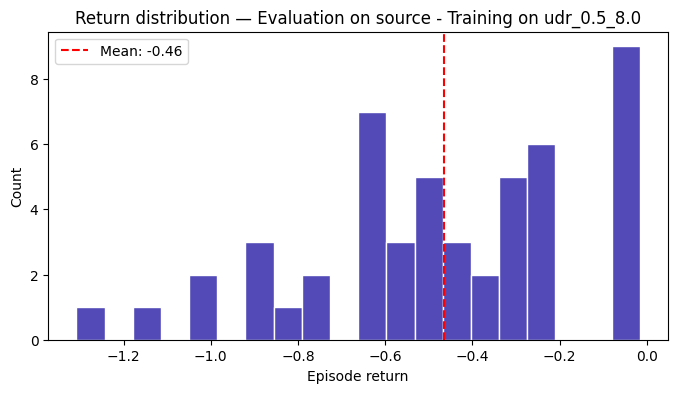

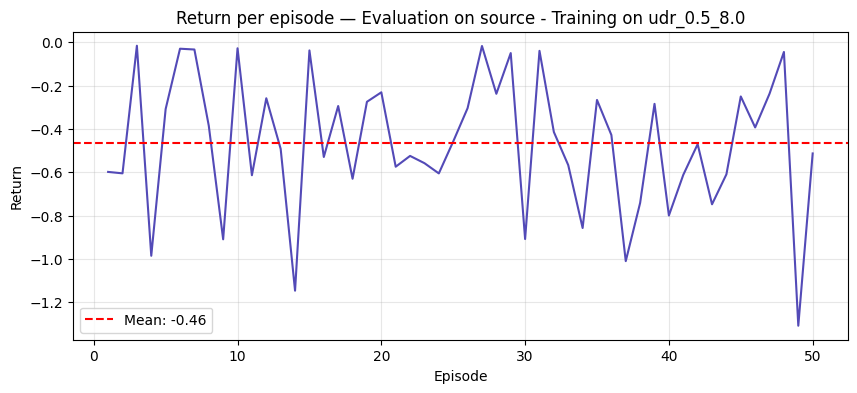

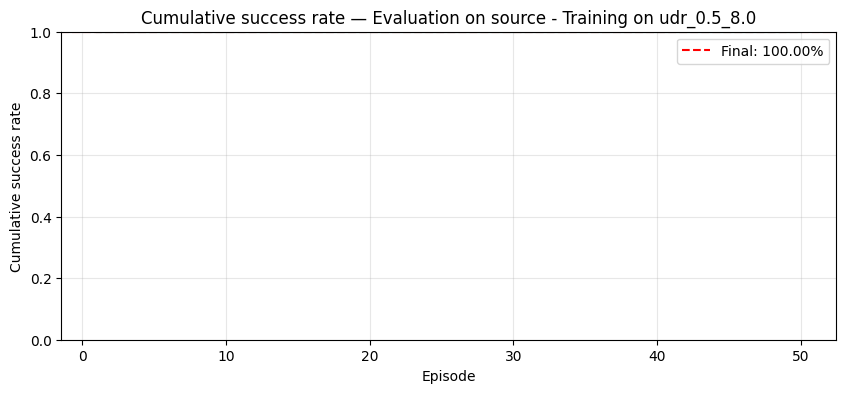

In [6]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26-main/results/udr_0.5_8.0/sac_push_udr_0.5_8.0_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="source", #args.env_type,
        env_training = "udr_0.5_8.0",
    )

**TEST ADR IN RANGE [0.8 , 1.2] - SOURCE**

Created object with mass: 1.0
Episode 001 | return = -3.966
Episode 002 | return = -3.382
Episode 003 | return = -0.016
Episode 004 | return = -1.194
Episode 005 | return = -0.326
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.441
Episode 009 | return = -0.733
Episode 010 | return = -0.028
Episode 011 | return = -0.905
Episode 012 | return = -0.303
Episode 013 | return = -0.615
Episode 014 | return = -3.141
Episode 015 | return = -0.037
Episode 016 | return = -4.251
Episode 017 | return = -0.317
Episode 018 | return = -0.902
Episode 019 | return = -0.343
Episode 020 | return = -0.249
Episode 021 | return = -3.752
Episode 022 | return = -0.588
Episode 023 | return = -0.699
Episode 024 | return = -0.547
Episode 025 | return = -0.553
Episode 026 | return = -0.459
Episode 027 | return = -0.017
Episode 028 | return = -0.251
Episode 029 | return = -0.050
Episode 030 | return = -1.541
Episode 031 | return = -0.039
Episode 032 | return = -0.475
Episode 03

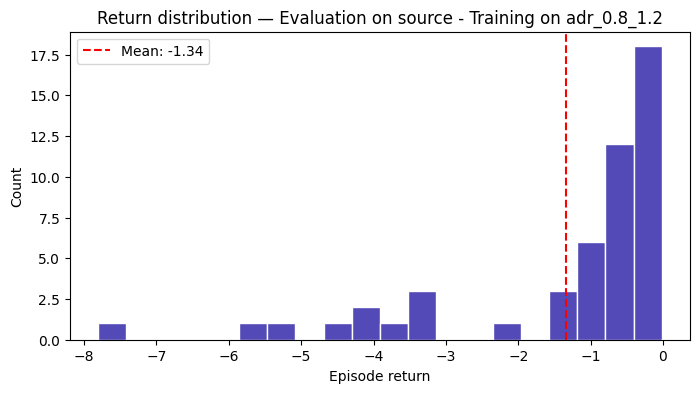

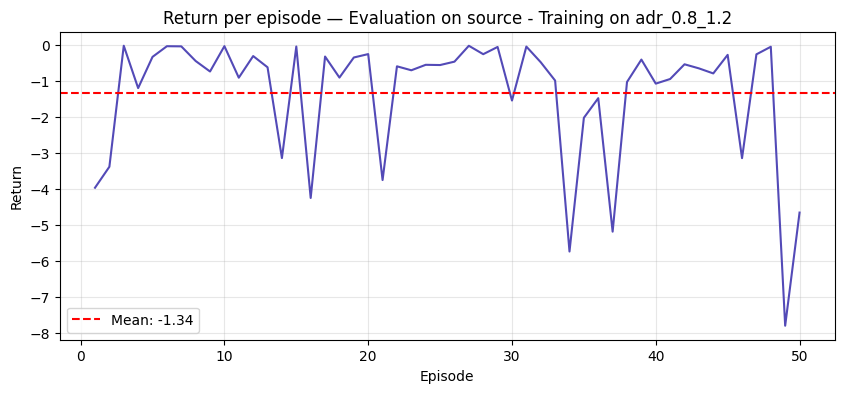

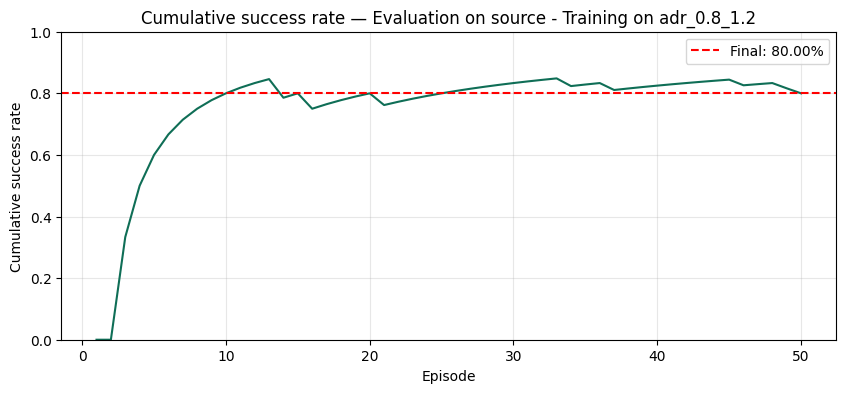

In [7]:
if __name__ == "__main__":
    #args = parse_args()
        evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26-main/results/adr_0.8_1.2/sac_push_adr_0.8_1.2_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="source", #args.env_type,
        env_training = "adr_0.8_1.2",
    )

**TEST UDR IN RANGE [0.5 , 6.0] - TARGET**

Created object with mass: 5.0
Episode 001 | return = -0.652
Episode 002 | return = -0.701
Episode 003 | return = -0.016
Episode 004 | return = -1.206
Episode 005 | return = -0.396
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.675
Episode 009 | return = -0.932
Episode 010 | return = -0.028
Episode 011 | return = -0.888
Episode 012 | return = -0.328
Episode 013 | return = -0.860
Episode 014 | return = -0.812
Episode 015 | return = -0.037
Episode 016 | return = -0.451
Episode 017 | return = -0.352
Episode 018 | return = -1.352
Episode 019 | return = -0.283
Episode 020 | return = -0.255
Episode 021 | return = -0.646
Episode 022 | return = -0.760
Episode 023 | return = -0.702
Episode 024 | return = -0.730
Episode 025 | return = -0.481
Episode 026 | return = -0.361
Episode 027 | return = -0.017
Episode 028 | return = -0.231
Episode 029 | return = -0.050
Episode 030 | return = -3.307
Episode 031 | return = -0.039
Episode 032 | return = -0.633
Episode 03

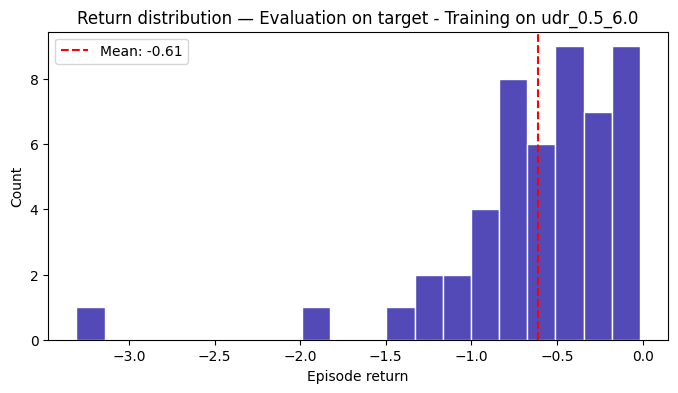

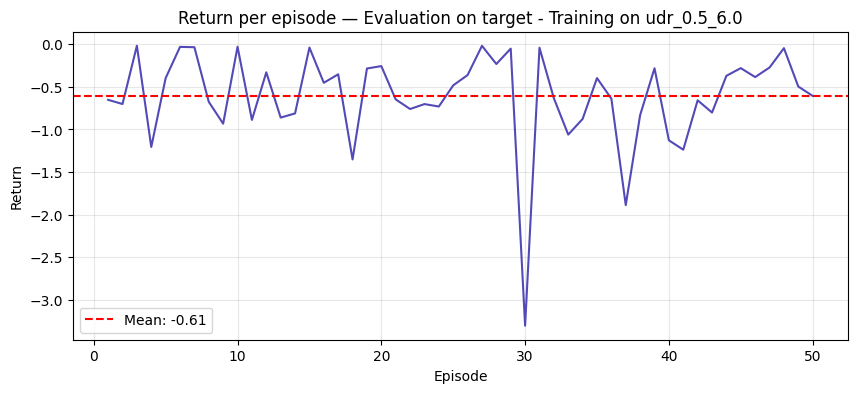

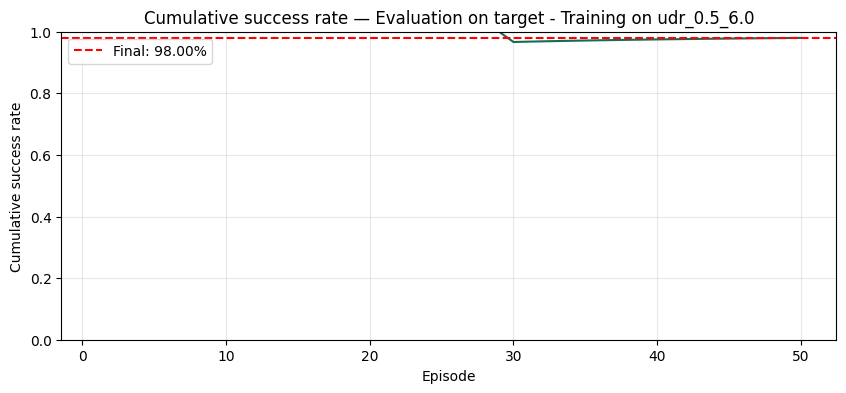

In [8]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26-main/results/udr_0.5_6.0/sac_push_udr_0.5_6.0_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="target", #args.env_type,
        env_training = "udr_0.5_6.0",
    )

**TEST UDR IN RANGE [0.5 , 8.0] - TARGET**

Created object with mass: 5.0
Episode 001 | return = -0.668
Episode 002 | return = -0.647
Episode 003 | return = -0.016
Episode 004 | return = -1.116
Episode 005 | return = -0.321
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.450
Episode 009 | return = -0.647
Episode 010 | return = -0.028
Episode 011 | return = -0.669
Episode 012 | return = -0.267
Episode 013 | return = -0.527
Episode 014 | return = -1.127
Episode 015 | return = -0.037
Episode 016 | return = -0.548
Episode 017 | return = -0.318
Episode 018 | return = -0.684
Episode 019 | return = -0.287
Episode 020 | return = -0.251
Episode 021 | return = -0.590
Episode 022 | return = -0.546
Episode 023 | return = -0.645
Episode 024 | return = -0.491
Episode 025 | return = -0.490
Episode 026 | return = -0.351
Episode 027 | return = -0.017
Episode 028 | return = -0.236
Episode 029 | return = -0.050
Episode 030 | return = -0.996
Episode 031 | return = -0.039
Episode 032 | return = -0.431
Episode 03

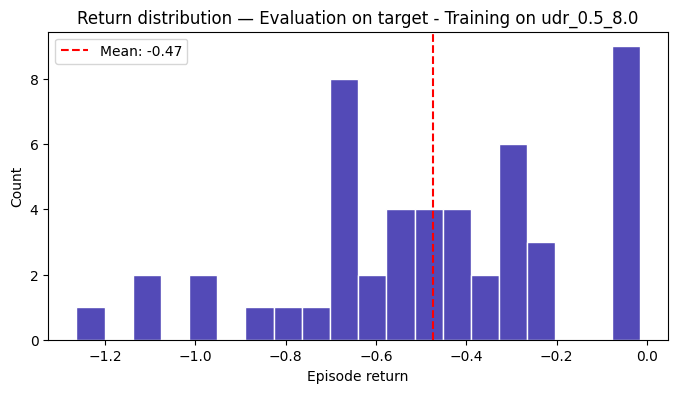

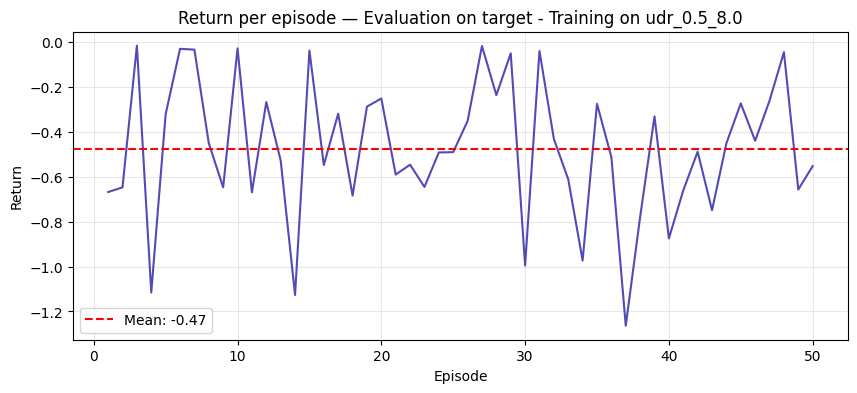

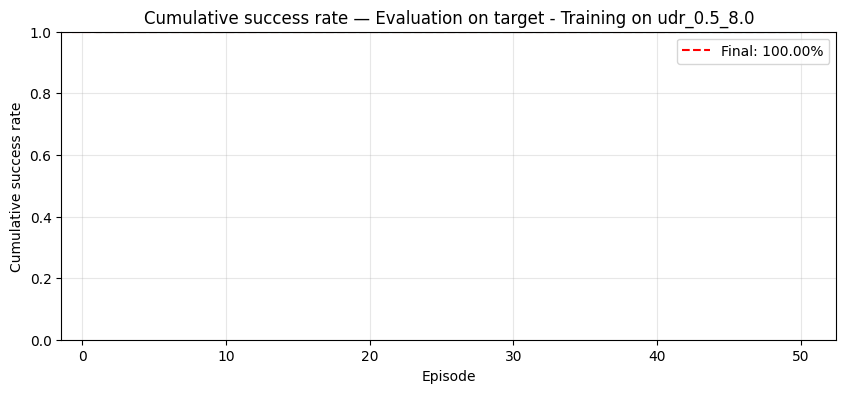

In [9]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26-main/results/udr_0.5_8.0/sac_push_udr_0.5_8.0_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="target", #args.env_type,
        env_training = "udr_0.5_8.0",
    )

**TEST ADR IN RANGE [0.8 , 1.2] - TARGET**

Created object with mass: 5.0
Episode 001 | return = -3.655
Episode 002 | return = -3.860
Episode 003 | return = -0.016
Episode 004 | return = -5.930
Episode 005 | return = -2.817
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -3.126
Episode 009 | return = -3.636
Episode 010 | return = -0.028
Episode 011 | return = -1.700
Episode 012 | return = -0.315
Episode 013 | return = -1.304
Episode 014 | return = -4.933
Episode 015 | return = -0.037
Episode 016 | return = -4.251
Episode 017 | return = -0.682
Episode 018 | return = -3.063
Episode 019 | return = -0.395
Episode 020 | return = -0.261
Episode 021 | return = -4.742
Episode 022 | return = -3.882
Episode 023 | return = -3.384
Episode 024 | return = -1.476
Episode 025 | return = -0.568
Episode 026 | return = -2.787
Episode 027 | return = -0.017
Episode 028 | return = -0.253
Episode 029 | return = -0.050
Episode 030 | return = -5.025
Episode 031 | return = -0.039
Episode 032 | return = -0.578
Episode 03

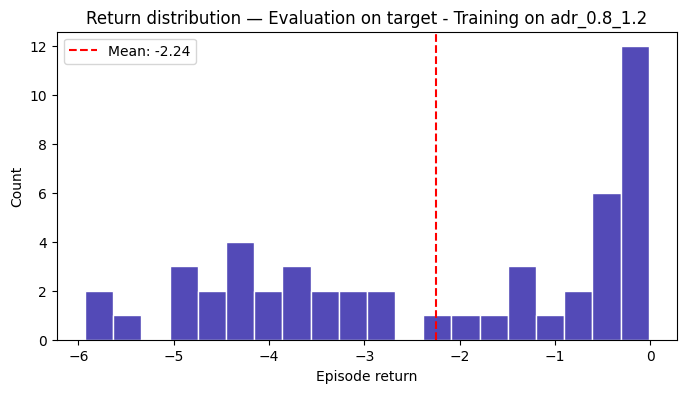

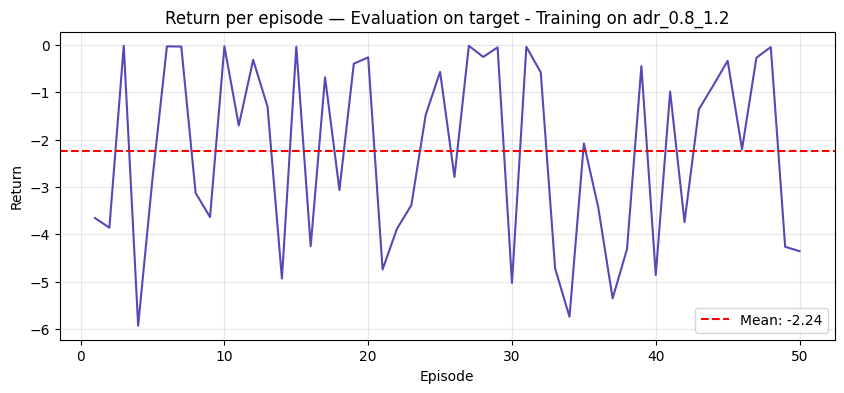

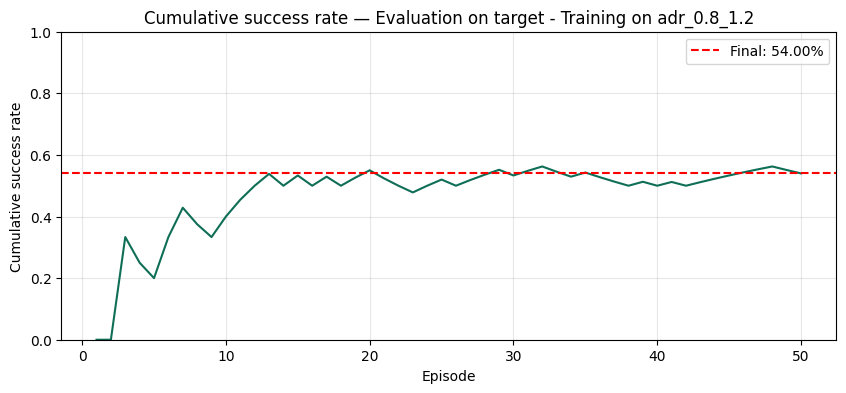

In [10]:
if __name__ == "__main__":
    #args = parse_args()
        evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26-main/results/adr_0.8_1.2/sac_push_adr_0.8_1.2_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="target", #args.env_type,
        env_training = "adr_0.8_1.2",
    )